# TP1 — Pipeline Machine Learning avec Scikit-learn  
## Énoncé de TP sans code — Classification des fleurs Iris

**Niveau : débutant / intermédiaire**  
**Durée estimée : 2h à 3h**  
**Module : Introduction à l’IA et au Machine Learning**

---

## Objectif général du TP

Ce TP a pour objectif de comprendre les principales étapes d’un **pipeline de Machine Learning** à partir d’un exemple simple : la classification des fleurs **Iris**.

L’étudiant devra suivre les consignes, compléter les cellules de travail dans son propre notebook et interpréter les résultats obtenus.

---

## Notions étudiées

- Chargement d’un jeu de données.
- Exploration initiale des données.
- Visualisation des données.
- Séparation train/test.
- Standardisation avec `StandardScaler`.
- Construction d’un pipeline ML.
- Entraînement d’un modèle de classification.
- Évaluation des performances.
- Interprétation des résultats.

# 1. Présentation du jeu de données Iris

Le jeu de données **Iris** est un dataset classique en Machine Learning.  
Il contient des mesures de fleurs appartenant à trois espèces :

- **setosa**
- **versicolor**
- **virginica**

Chaque fleur est décrite par quatre variables :

1. longueur du sépale ;
2. largeur du sépale ;
3. longueur du pétale ;
4. largeur du pétale.

La variable à prédire est l’**espèce de la fleur**.

---

## Travail demandé

1. Charger le dataset Iris.
2. Afficher :
   - le nombre d’observations ;
   - le nombre de variables ;
   - les noms des variables ;
   - les noms des classes.
3. Expliquer en une phrase ce que représente chaque observation.

# 2. Création d’un tableau de données

Les données brutes sont souvent difficiles à lire.  
Il est donc utile de les transformer en tableau de type `DataFrame`.

---

## Travail demandé

1. Créer un tableau contenant les quatre variables du dataset.
2. Ajouter une colonne contenant la classe numérique.
3. Ajouter une colonne contenant le nom de l’espèce.
4. Afficher les cinq premières lignes du tableau.
5. Afficher une description statistique des variables.

---

## Questions

1. Combien y a-t-il de fleurs dans le dataset ?
2. Combien y a-t-il de variables explicatives ?
3. Quelle est la variable cible ?
4. Les variables sont-elles toutes numériques ?

# 3. Analyse de la distribution des classes

Avant de construire un modèle, il faut vérifier si les classes sont équilibrées.

Un dataset est **équilibré** lorsque chaque classe contient à peu près le même nombre d’observations.

---

## Travail demandé

1. Compter le nombre d’exemples pour chaque espèce.
2. Représenter cette distribution sous forme de graphique en barres.
3. Commenter le résultat.

---

## Questions

1. Les classes sont-elles équilibrées ?
2. Pourquoi un déséquilibre des classes peut-il poser problème en Machine Learning ?
3. Dans ce dataset, ce problème semble-t-il important ?

# 4. Visualisation des données

La visualisation permet de mieux comprendre les données avant de construire un modèle.

Dans ce TP, il est demandé de visualiser les fleurs selon deux variables :

- longueur du pétale ;
- largeur du pétale.

---

## Travail demandé

1. Créer un nuage de points.
2. Utiliser une couleur ou un symbole différent pour chaque espèce.
3. Ajouter un titre, les labels des axes et une légende.
4. Observer la séparation entre les classes.

---

## Questions

1. Quelle espèce semble la plus facile à séparer ?
2. Quelles espèces semblent les plus proches ?
3. Les variables liées aux pétales semblent-elles utiles pour la classification ?

# 5. Visualisation des variables une par une

Une seule visualisation ne suffit pas toujours.  
Il est aussi utile d’observer la distribution de chaque variable selon l’espèce.

---

## Travail demandé

1. Pour chacune des quatre variables, afficher un histogramme.
2. Comparer les distributions selon les trois espèces.
3. Identifier les variables qui semblent les plus discriminantes.

---

## Questions

1. Les variables liées aux sépales permettent-elles de bien séparer les classes ?
2. Les variables liées aux pétales sont-elles plus utiles ?
3. Quelle variable semble la plus importante visuellement ?

# 6. Séparation des données : train/test

Un modèle de Machine Learning doit être évalué sur des données qu’il n’a pas utilisées pendant l’apprentissage.

On sépare donc les données en deux ensembles :

- **train set** : utilisé pour entraîner le modèle ;
- **test set** : utilisé pour évaluer le modèle.

---

## Travail demandé

1. Séparer les données en deux parties :
   - 80 % pour l’entraînement ;
   - 20 % pour le test.
2. Conserver la même proportion de classes dans les deux ensembles.
3. Afficher la taille de chaque ensemble.

---

## Questions

1. Pourquoi ne faut-il pas évaluer le modèle uniquement sur les données d’entraînement ?
2. À quoi sert le jeu de test ?
3. Pourquoi utilise-t-on un `random_state` ?

# 7. StandardScaler : standardisation des variables

Le **StandardScaler** est une étape de prétraitement qui transforme les variables numériques pour qu’elles aient :

- une moyenne proche de 0 ;
- un écart-type proche de 1.

La formule générale est :

```text
valeur standardisée = (valeur - moyenne) / écart-type
```

---

## Pourquoi standardiser ?

Certaines méthodes de Machine Learning sont sensibles à l’échelle des variables.  
Si une variable a des valeurs beaucoup plus grandes qu’une autre, elle peut influencer excessivement le modèle.

Même si la forêt aléatoire est moins sensible à l’échelle, utiliser `StandardScaler` dans un pipeline reste utile pour apprendre une bonne pratique générale.

---

## Travail demandé

1. Expliquer le rôle du `StandardScaler`.
2. Identifier les variables qui seront standardisées.
3. Expliquer pourquoi la standardisation doit être calculée uniquement sur le jeu d’entraînement.
4. Expliquer la différence entre :
   - `fit_transform` ;
   - `transform`.

---

## Questions

1. Le StandardScaler change-t-il la classe des observations ?
2. Change-t-il l’ordre relatif des valeurs ?
3. Pourquoi ne faut-il pas faire `fit_transform` sur le jeu de test ?

# 8. Construction du pipeline Machine Learning

Un **pipeline** permet d’enchaîner plusieurs étapes dans un ordre précis.

Dans ce TP, le pipeline doit contenir :

1. une étape de standardisation ;
2. une étape de classification.

Le modèle utilisé est une **forêt aléatoire**.

---

## Rappel : Random Forest

Une forêt aléatoire est un ensemble de plusieurs arbres de décision.  
Chaque arbre propose une prédiction, puis le modèle combine les prédictions pour produire la décision finale.

---

## Travail demandé

1. Créer un pipeline contenant :
   - `StandardScaler` ;
   - `RandomForestClassifier`.
2. Utiliser un nombre raisonnable d’arbres.
3. Fixer un `random_state` pour rendre les résultats reproductibles.

---

## Questions

1. Pourquoi le pipeline est-il utile ?
2. Que se passe-t-il dans la première étape du pipeline ?
3. Que se passe-t-il dans la deuxième étape ?

# 9. Entraînement du modèle

L’entraînement consiste à faire apprendre le modèle à partir des données d’entraînement.

Le modèle observe les variables explicatives et les classes associées, puis apprend des règles de décision.

---

## Travail demandé

1. Entraîner le pipeline sur le jeu d’entraînement.
2. Vérifier que l’entraînement s’est bien déroulé.
3. Expliquer en une phrase ce que le modèle a appris.

---

## Questions

1. Quelles données sont utilisées pendant l’entraînement ?
2. Le modèle doit-il voir les données de test pendant l’entraînement ?
3. Pourquoi ?

# 10. Prédiction sur le jeu de test

Une fois le modèle entraîné, on l’utilise pour prédire les classes des observations du jeu de test.

---

## Travail demandé

1. Utiliser le modèle pour prédire les classes du jeu de test.
2. Créer un tableau comparant :
   - la vraie classe ;
   - la classe prédite.
3. Afficher les premières prédictions.

---

## Questions

1. Certaines prédictions sont-elles incorrectes ?
2. Si oui, quelles classes sont confondues ?
3. Est-ce cohérent avec les visualisations précédentes ?

# 11. Évaluation du modèle

L’évaluation permet de mesurer la qualité du modèle.

Les indicateurs à observer sont :

- **accuracy** ;
- **precision** ;
- **recall** ;
- **F1-score**.

---

## Travail demandé

1. Calculer l’accuracy du modèle.
2. Afficher le rapport de classification.
3. Interpréter les résultats pour chaque classe.

---

## Questions

1. Que signifie une accuracy élevée ?
2. Pourquoi l’accuracy ne suffit-elle pas toujours ?
3. Quelle classe est la mieux prédite ?
4. Quelle classe semble la plus difficile à prédire ?

# 12. Matrice de confusion

La matrice de confusion montre les bonnes et les mauvaises prédictions.

Les lignes représentent les vraies classes.  
Les colonnes représentent les classes prédites.

---

## Travail demandé

1. Afficher la matrice de confusion.
2. Identifier les bonnes prédictions.
3. Identifier les erreurs.
4. Commenter les confusions entre classes.

---

## Questions

1. Où se trouvent les bonnes prédictions dans la matrice ?
2. Quelles classes sont confondues ?
3. Pourquoi la matrice de confusion est-elle plus informative que l’accuracy seule ?

# 13. Importance des variables

Certains modèles, comme la forêt aléatoire, permettent d’estimer l’importance des variables.

Une variable importante est une variable qui aide fortement le modèle à prendre une décision.

---

## Travail demandé

1. Extraire l’importance des variables.
2. Créer un tableau avec :
   - le nom de la variable ;
   - son importance.
3. Représenter les importances avec un graphique en barres.
4. Interpréter le résultat.

---

## Questions

1. Quelles variables sont les plus importantes ?
2. Est-ce cohérent avec les visualisations ?
3. Peut-on dire qu’une variable importante est forcément la cause de la classe ?

# 14. Visualisation simplifiée d’un arbre de décision

Une forêt aléatoire contient plusieurs arbres de décision.

Pour mieux comprendre le fonctionnement du modèle, on peut visualiser un arbre de manière simplifiée.

---

## Travail demandé

1. Extraire un arbre de la forêt.
2. Afficher cet arbre avec une profondeur limitée.
3. Observer les règles de séparation.
4. Identifier les variables utilisées dans les premières décisions.

---

## Questions

1. Quelle variable apparaît au début de l’arbre ?
2. Pourquoi limite-t-on la profondeur de l’arbre pour l’affichage ?
3. Un seul arbre est-il équivalent à toute la forêt ?

# 15. Comparaison avec et sans pipeline

Un pipeline n’est pas obligatoire, mais il rend le code plus propre et plus sûr.

Sans pipeline, il faut gérer séparément :

- la standardisation ;
- l’entraînement ;
- la prédiction ;
- l’évaluation.

Avec pipeline, les étapes sont regroupées.

---

## Travail demandé

1. Expliquer la différence entre une approche avec pipeline et une approche sans pipeline.
2. Identifier les risques d’une approche sans pipeline.
3. Justifier l’intérêt du pipeline dans un projet réel.

---

## Questions

1. Quelle approche est la plus organisée ?
2. Quelle approche limite mieux les erreurs de prétraitement ?
3. Pourquoi le pipeline est-il utile pour la reproductibilité ?

# 16. Mini-exercices

## Exercice 1 — Nombre d’arbres

Modifier le nombre d’arbres de la forêt aléatoire.

Tester par exemple :

- 10 arbres ;
- 50 arbres ;
- 100 arbres ;
- 200 arbres.

### Question

L’accuracy change-t-elle beaucoup ?

---

## Exercice 2 — Taille du jeu de test

Modifier la taille du jeu de test.

Tester par exemple :

- 20 % ;
- 30 % ;
- 40 %.

### Question

Les résultats restent-ils stables ?

---

## Exercice 3 — Variables importantes

Observer les importances des variables.

### Question

Les variables les plus importantes sont-elles les mêmes que celles observées dans les graphiques ?

---

## Exercice 4 — Interprétation

Rédiger un court paragraphe expliquant :

- ce que fait le pipeline ;
- pourquoi les données sont visualisées ;
- comment le modèle est évalué.

# 17. Questions de synthèse

Répondre brièvement aux questions suivantes.

1. Qu’est-ce qu’un pipeline en Machine Learning ?
2. Pourquoi faut-il visualiser les données avant la modélisation ?
3. Quel est le rôle du `StandardScaler` ?
4. Pourquoi faut-il séparer les données en train/test ?
5. À quoi sert la matrice de confusion ?
6. Quelle est la différence entre accuracy et F1-score ?
7. Pourquoi l’importance des variables est-elle utile ?
8. Quelles sont les limites de ce TP ?

# 18. Travail à rendre

L’étudiant doit remettre :

1. un notebook complété ;
2. les graphiques générés ;
3. une courte interprétation de chaque graphique ;
4. les résultats d’évaluation du modèle ;
5. une conclusion de 5 à 10 lignes.

---

## Conclusion attendue

La conclusion doit expliquer :

- si le modèle fonctionne bien ;
- quelles variables sont les plus utiles ;
- quelles classes sont faciles ou difficiles à distinguer ;
- pourquoi le pipeline est utile ;
- quelles améliorations pourraient être envisagées.

# 19. Corrigé indicatif — éléments attendus

## Visualisation

Les classes sont généralement équilibrées.  
Les variables liées aux pétales permettent souvent de mieux séparer les espèces que les variables liées aux sépales.

## StandardScaler

Le StandardScaler centre et réduit les variables.  
Il doit être ajusté uniquement sur le jeu d’entraînement pour éviter toute fuite d’information.

## Pipeline

Le pipeline permet d’organiser les étapes de prétraitement et de modélisation.  
Il applique les mêmes transformations aux données d’entraînement et aux données de test.

## Évaluation

Une bonne accuracy indique que le modèle prédit correctement une grande partie des observations.  
La matrice de confusion permet de voir précisément quelles classes sont confondues.

## Interprétation

Les erreurs apparaissent souvent entre `versicolor` et `virginica`, car ces deux classes sont plus proches dans l’espace des variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.tree import plot_tree

print("Bibiothèques importées avec succès")

Bibiothèques importées avec succès


In [2]:
iris = load_iris()

x = iris.data
y = iris.target

print("dimension de x :", x.shape)
print("nombre d'observations :",x.shape[0])
print("nombre de variable :",x.shape[1])
print("Classes :",iris.target_names)
print("variable :",iris.feature_names)

dimension de x : (150, 4)
nombre d'observations : 150
nombre de variable : 4
Classes : ['setosa' 'versicolor' 'virginica']
variable : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
df = pd.DataFrame(x, columns=iris.feature_names)
df['target'] = y
df["species"] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


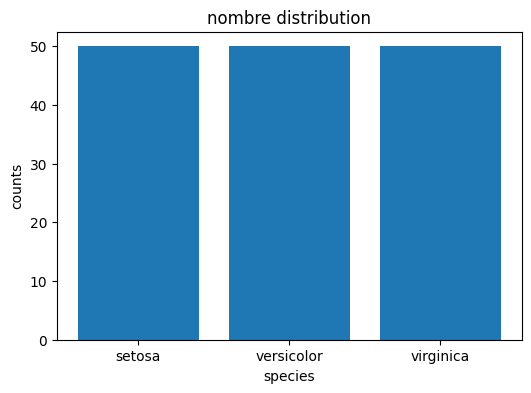

In [8]:
class_counts = df["species"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index,class_counts.values)
plt.xlabel("species")
plt.ylabel("counts")
plt.title("nombre distribution")
plt.show()

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("taille du train set :", x_train.shape)
print("taille du test set :", x_test.shape)

taille du train set : (120, 4)
taille du test set : (30, 4)


In [10]:
pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("classifier",RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [11]:
pipeline.fit(x_train, y_train)
print("Pipeline entrainé avec succès")

Pipeline entrainé avec succès


In [13]:
y_pred = pipeline.predict(x_test)

resultat = pd.DataFrame({
    'classe réelle':y_test,
    'classe predite':y_pred
})

resultat.head(10)

,classe réelle,classe predite
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


In [15]:
accuracy= accuracy_score(y_test, y_pred)
print(f"accuracy{accuracy:.2f}")
print("\rapport de classification")
print(classification_report(y_test, y_pred,target_names = iris.target_names))

accuracy0.90
apport de classification
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

